# Chatbot project

This notebook trains a chatbot from scratch using 3 complementary datasets:
- **Cornell Movie Dialogs** has over 80,000 conversations from movie scripts. Dramatic, varied, sometimes over-the-top, but broad vocabulary.
- **DailyDialog** with over 13,000 everyday conversations. More natural, polite, and grounded than movie dialogue.
- **EmpatheticDialogues** combines over 24,000 short conversations that have very empathetic feeling.

### What happens in each step
1. **Setup** — imports, GPU detection, mixed precision
2a. **Load Cornell** — download ZIP directly from Cornell University
2b. **Load DailyDialog** — load from HuggingFace (no custom scripts, safe)
2c. **Load EmpatheticDialogues** — load from HuggingFace (no custom scripts, safe)
3. **Preprocess** — parse, clean, extract multi-turn windows from both datasets
4. **Tokenize** — train SentencePiece BPE tokenizer on the combined corpus
5. **Build sequences** — sliding window over token stream
6. **Define model** — causal transformer
7. **Train** — training loop with callbacks
8. **Plot** — training history
9. **Chat** — test the model with prompts
10. **Save** — model and tokenizer to disk
11. **Reload** — optional, load saved model without retraining

### Requirements
```
pip install sentencepiece datasets ftfy
```

## Cell 1 Setup

Imports, GPU detection, and mixed precision configuration.

- If a GPU is found, **mixed precision** is enabled, computations use 16-bit numbers (faster) while weights stay in 32-bit (accurate). Roughly 2x speedup on RTX cards.
- If no GPU is found the model will still train on CPU, just slower.

In [1]:
import os, re, json, logging, tempfile, unicodedata, urllib.request, zipfile, io, random

# Must be set before importing Keras
os.environ['KERAS_BACKEND']        = 'tensorflow'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_DEVICE_ORDER']    = 'PCI_BUS_ID'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np
import tensorflow as tf
import keras
import sentencepiece as spm
import ftfy
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detected: {gpus[0].name}")
    keras.mixed_precision.set_global_policy('mixed_float16')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = 'GPU'
else:
    print("No GPU detected — running on CPU (training will be slower)")
    keras.mixed_precision.set_global_policy('float32')
    DEVICE = 'CPU'

print(f"Keras {keras.__version__} | Backend: {keras.config.backend()} | Device: {DEVICE} | Precision: {keras.mixed_precision.global_policy().name}")

GPU detected: /physical_device:GPU:0
Keras 3.0.5 | Backend: tensorflow | Device: GPU | Precision: mixed_float16


## Cell 2a Load the Cornell Movie Dialogs corpus

We download the ZIP directly from Cornell University's servers using Python's built-in `urllib`. No third-party loading scripts. The ZIP contains `utterances.jsonl`, one JSON object per spoken line, with a `conversation_id` field that groups lines into conversations.

The file is stored in reverse chronological order so we use `insert(0, ...)` to reconstruct the correct conversation sequence.

In [2]:
CORPUS_URL = "https://zissou.infosci.cornell.edu/convokit/datasets/movie-corpus/movie-corpus.zip"

print("[1/3] Downloading Cornell Movie Dialogs corpus...")
with urllib.request.urlopen(CORPUS_URL) as response:
    zip_bytes = response.read()
print(f"      Downloaded {len(zip_bytes) / 1e6:.1f} MB")

print("[2/3] Opening ZIP and locating utterances file...")
zf = zipfile.ZipFile(io.BytesIO(zip_bytes))
utterances_file = next(n for n in zf.namelist() if n.endswith('utterances.jsonl'))
print(f"      Found: {utterances_file}")

print("[3/3] Parsing utterances and grouping into conversations...")
cornell_conversations = {}  # conv_id -> list of {lineID, text} in chronological order

with zf.open(utterances_file) as f:
    for raw_line in f:
        utt      = json.loads(raw_line)
        conv_id  = utt["conversation_id"]
        line_obj = {"lineID": utt["id"], "text": utt.get("text", "").strip()}

        # File is stored newest-first, insert at front to restore chronological order
        if conv_id not in cornell_conversations:
            cornell_conversations[conv_id] = [line_obj]
        else:
            cornell_conversations[conv_id].insert(0, line_obj)

total_lines = sum(len(v) for v in cornell_conversations.values())
print(f"Conversations: {len(cornell_conversations):,}")
print(f"Total lines:   {total_lines:,}")
print("Done.")

[1/3] Downloading Cornell Movie Dialogs corpus...
      Downloaded 40.9 MB
[2/3] Opening ZIP and locating utterances file...
      Found: movie-corpus/utterances.jsonl
[3/3] Parsing utterances and grouping into conversations...
Conversations: 83,097
Total lines:   304,713
Done.


## Cell 2b Load DailyDialog

**DailyDialog** is a dataset of ~13,000 everyday English conversations covering topics like shopping, travel, health, and weather. Unlike movie scripts it uses clean, polite, natural language, which complements Cornell's more dramatic vocabulary.

It loads cleanly from HuggingFace without any custom scripts (`trust_remote_code` is not needed here). Each entry has a `dialog` field which is already a list of utterances in order so no reconstruction needed.

We combine all three splits (train, validation, test) and convert to the same `{lineID, text}` list format as Cornell so both datasets go through identical preprocessing.

In [3]:
print("[1/3] Downloading DailyDialog parquet files directly (no datasets library)...")

# HuggingFace stores auto-converted parquet at a predictable URL pattern.
# We fetch each split directly with urllib, bypassing load_dataset entirely.
BASE_URL = (
    "https://huggingface.co/datasets/roskoN/dailydialog"
    "/resolve/refs%2Fconvert%2Fparquet/full"
)

splits_raw = {}
for split in ("train", "validation", "test"):
    print(f"      Fetching {split}...")
    url = f"{BASE_URL}/{split}/0000.parquet"
    with urllib.request.urlopen(url) as resp:
        splits_raw[split] = pd.read_parquet(io.BytesIO(resp.read()))

total_rows = sum(len(df) for df in splits_raw.values())
print(f"      Total conversations downloaded: {total_rows:,}")

print("[2/3] Converting to conversation format...")
daily_conversations = {}

for split_name, df in splits_raw.items():
    for i, row in df.iterrows():
        conv_id   = f"dd_{split_name}_{i}"
        # 'utterances' column is a list of plain strings. One per turn
        line_objs = [
            {"lineID": f"{conv_id}_L{j}", "text": turn.strip()}
            for j, turn in enumerate(row["utterances"])
            if turn.strip()
        ]
        if len(line_objs) >= 2:
            daily_conversations[conv_id] = line_objs

total_dd_lines = sum(len(v) for v in daily_conversations.values())
print(f"      Conversations: {len(daily_conversations):,}")
print(f"      Total lines:   {total_dd_lines:,}")

print("[3/3] Verifying sample...")
sample_key = list(daily_conversations.keys())[0]
print("\nSample DailyDialog conversation:")
for line in daily_conversations[sample_key][:4]:
    print(f"  {line['text']}")
print("")
print("Done.")

[1/3] Downloading DailyDialog parquet files directly (no datasets library)...
      Fetching train...
      Fetching validation...
      Fetching test...
      Total conversations downloaded: 13,118
[2/3] Converting to conversation format...
      Conversations: 13,118
      Total lines:   102,979
[3/3] Verifying sample...

Sample DailyDialog conversation:
  Say , Jim , how about going for a few beers after dinner ?
  You know that is tempting but is really not good for our fitness .
  What do you mean ? It will help us to relax .
  Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?

Done.


## Cell 2c Load EmpatheticDialogues

**EmpatheticDialogues** is a dataset of 25,000 conversations created by Facebook Research, 
where each dialogue is grounded in a specific emotional situation. 
One speaker describes something that happened to them (a job loss, an exciting achievement, a scary moment), 
and the other responds empathetically. 
This adds something neither Cornell nor DailyDialog has, conversations where the emotional context drives what gets said next.

We use `Estwld/empathetic_dialogues_llm`, which is a clean reformatting of the original dataset into a simple `{role, content}` structure, 
stored as pure parquet with no loading script. 
All three splits (train, valid, test) are used since we are training, not evaluating.

One thing to be aware of: the original dataset contains `_comma_` as a placeholder for commas (an artifact of how it was collected). 
This version has already replaced those with real commas, so no extra cleaning is needed on our end.

In [4]:
print("[1/2] Downloading EmpatheticDialogues parquet files...")

BASE_URL_ED = (
    "https://huggingface.co/datasets/Estwld/empathetic_dialogues_llm"
    "/resolve/refs%2Fconvert%2Fparquet/default"
)

ed_frames = {}
for split in ("train", "valid", "test"):
    print(f"      Fetching {split}...")
    url = f"{BASE_URL_ED}/{split}/0000.parquet"
    with urllib.request.urlopen(url) as resp:
        ed_frames[split] = pd.read_parquet(io.BytesIO(resp.read()))

total_ed = sum(len(df) for df in ed_frames.values())
print(f"      Total conversations downloaded: {total_ed:,}")

print("[2/2] Converting EmpatheticDialogues to conversation format...")
empathetic_conversations = {}

for split_name, df in ed_frames.items():
    for i, row in df.iterrows():
        conv_id  = f"ed_{split_name}_{i}"
        # 'conversations' is a list of {"role": "user"/"assistant", "content": "..."}
        # We extract just the content in order, roles already alternate correctly
        line_objs = [
            {"lineID": f"{conv_id}_L{j}", "text": msg["content"].strip()}
            for j, msg in enumerate(row["conversations"])
            if msg["content"].strip()
        ]
        if len(line_objs) >= 2:
            empathetic_conversations[conv_id] = line_objs

total_ed_lines = sum(len(v) for v in empathetic_conversations.values())
print(f"      Conversations: {len(empathetic_conversations):,}")
print(f"      Total lines:   {total_ed_lines:,}")
print("Done.")

sample_key = list(empathetic_conversations.keys())[0]
print("\nSample EmpatheticDialogues conversation:")
for line in empathetic_conversations[sample_key][:4]:
    print(f"  {line['text']}")

[1/2] Downloading EmpatheticDialogues parquet files...
      Fetching train...
      Fetching valid...
      Fetching test...
      Total conversations downloaded: 24,850
[2/2] Converting EmpatheticDialogues to conversation format...
      Conversations: 24,847
      Total lines:   107,214
Done.

Sample EmpatheticDialogues conversation:
  I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.
  Was this a friend you were in love with, or just a best friend?
  This was a best friend. I miss her.
  Where has she gone?


## Cell 3 Preprocess: clean text and extract multi-turn windows

This cell does the heavy lifting. The same functions run on all the datasets.

**Text normalization**:
- Fix encoding artifacts with `ftfy`
- Convert accented characters to plain ASCII
- Lowercase everything
- Space out punctuation so `.` `!` `?` become their own tokens
- Remove anything that is not a letter or those three punctuation marks

**Multi-turn extraction** Instead of isolated pairs we slide a window of `CONTEXT_TURNS` exchanges across each conversation. Each window becomes one training block. For `CONTEXT_TURNS=3` on a 6-line conversation this produces overlapping 6-line blocks, stepping by 2 lines each time. This teaches the model to use prior turns when generating its reply.

In [5]:
CONTRACTIONS = {
    "won't":     "will not",
    "can't":     "cannot",
    "ain't":     "is not",
    "i'm":       "i am",
    "i've":      "i have",
    "i'll":      "i will",
    "i'd":       "i would",
    "it's":      "it is",
    "he's":      "he is",
    "she's":     "she is",
    "that's":    "that is",
    "there's":   "there is",
    "here's":    "here is",
    "who's":     "who is",
    "what's":    "what is",
    "let's":     "let us",
    "you're":    "you are",
    "you've":    "you have",
    "you'll":    "you will",
    "you'd":     "you would",
    "we're":     "we are",
    "we've":     "we have",
    "we'll":     "we will",
    "we'd":      "we would",
    "they're":   "they are",
    "they've":   "they have",
    "they'll":   "they will",
    "they'd":    "they would",
    "he'd":      "he would",
    "she'd":     "she would",
    "he'll":     "he will",
    "she'll":    "she will",
    "isn't":     "is not",
    "aren't":    "are not",
    "wasn't":    "was not",
    "weren't":   "were not",
    "hasn't":    "has not",
    "haven't":   "have not",
    "hadn't":    "had not",
    "doesn't":   "does not",
    "don't":     "do not",
    "didn't":    "did not",
    "wouldn't":  "would not",
    "couldn't":  "could not",
    "shouldn't": "should not",
    "mustn't":   "must not",
    "needn't":   "need not",
}

In [6]:
CONTEXT_TURNS = 2   # was 3 — requires only 4 lines per window, not 6
MIN_LENGTH    = 1   # was 2 — stop discarding short but valid lines
MAX_LENGTH    = 25  # was 20 — relax slightly to keep more windows

# Strip accents and diacritics, returning a plain ASCII string.
# Example: 'cafe\u0301' (cafe with accent) -> 'cafe'
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

# Replace contractions with their full forms before stripping punctuation.
# This must run after lowercasing so dictionary keys always match.
def expand_contractions(s):
    for contraction, expansion in CONTRACTIONS.items():
        # \b matches a word boundary, prevents partial matches
        s = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, s)
    return s

# Normalizing strings
def normalize_string(s):
    s = ftfy.fix_text(s)
    s = unicode_to_ascii(s.lower().strip())
    s = expand_contractions(s)
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    s = re.sub(r"\s+", r" ", s).strip()
    return s


# Extract overlapping multi-turn conversation windows.
# For CONTEXT_TURNS=3 and a conversation [A, B, C, D, E, F], this produces:
#         Window 1: Human:A  Bot:B  Human:C  Bot:D  Human:E  Bot:F
#         (if len >= 6; steps of 2 lines produce more windows for longer conversations)
def extract_multiturn_blocks(conversations, min_len=MIN_LENGTH, max_len=MAX_LENGTH, context_turns=CONTEXT_TURNS):
    blocks      = []
    window_size = context_turns * 2  # 2 lines per turn (one Human + one Bot)

    for line_objs in conversations.values():
        # Normalize all lines upfront so we only call normalize_string once per line
        lines = [normalize_string(obj["text"]) for obj in line_objs]
        lines = [l for l in lines if l]   # Drop lines that became empty after cleaning

        if len(lines) < window_size:
            continue   # Not enough lines for a single full window

        # Slide the window by 2 lines at a time (one exchange per step)
        for start in range(0, len(lines) - window_size + 1, 2):
            window = lines[start : start + window_size]

            # Skip this window if any line falls outside the word-count limits
            if not all(min_len <= len(l.split()) <= max_len for l in window):
                continue

            # Build formatted block — lines alternate Human/Bot
            turns = []
            for i in range(0, window_size, 2):
                turns.append(f"Human: {window[i]}")
                turns.append(f"Bot: {window[i + 1]}")
            blocks.append("\n".join(turns))

    return blocks


# Process datasets
print("[1/4] Extracting multi-turn windows from Cornell Movie Dialogs...")
cornell_blocks = extract_multiturn_blocks(cornell_conversations)
print(f"      Windows: {len(cornell_blocks):,}")

print("[2/4] Extracting multi-turn windows from DailyDialog...")
daily_blocks = extract_multiturn_blocks(daily_conversations)
print(f"      Windows: {len(daily_blocks):,}")

print("[3/4] Extracting multi-turn windows from EmpatheticDialogues...")
empathetic_blocks = extract_multiturn_blocks(empathetic_conversations)
print(f"      Windows: {len(empathetic_blocks):,}")

print("[4/4] Merging, shuffling, and building corpus...")
all_blocks = cornell_blocks + daily_blocks + empathetic_blocks
random.seed(42)
random.shuffle(all_blocks)
full_corpus = "\n\n".join(all_blocks)
print(f"      Total windows: {len(all_blocks):,}")
print(f"      Total characters: {len(full_corpus):,}")

print("\nSample Cornell window:")
print(cornell_blocks[0])
print("\nSample DailyDialog window:")
print(daily_blocks[0])
print("\nSample EmpatheticDialogues window:")
print(empathetic_blocks[0])
print("\nDone.")

[1/4] Extracting multi-turn windows from Cornell Movie Dialogs...
      Windows: 33,597
[2/4] Extracting multi-turn windows from DailyDialog...
      Windows: 25,935
[3/4] Extracting multi-turn windows from EmpatheticDialogues...
      Windows: 17,508
[4/4] Merging, shuffling, and building corpus...
      Total windows: 77,040
      Total characters: 15,973,774

Sample Cornell window:
Human: i figured you would get to the good stuff eventually .
Bot: what good stuff ?
Human: the real you .
Bot: like my fear of wearing pastels ?

Sample DailyDialog window:
Human: say jim how about going for a few beers after dinner ?
Bot: you know that is tempting but is really not good for our fitness .
Human: what do you mean ? it will help us to relax .
Bot: do you really think so ? i do not . it will just make us fat and act silly . remember last time ?

Sample EmpatheticDialogues window:
Human: this was a best friend . i miss her .
Bot: where has she gone ?
Human: we no longer talk .
Bot: oh was th

## Cell 4 Train the tokenizer

We use **Byte Pair Encoding (BPE)** via SentencePiece. Common words become single tokens and rare or unseen words are split into subword pieces, so the model can handle any input.

Vocabulary is 6,000 tokens which should be enaugh for a simple chatbot.

`Human:` and `Bot:` are registered as protected symbols so the tokenizer never splits these label words across subwords, they need to stay intact as unambiguous signals to the model.

In [7]:
VOCAB_SIZE = 6000

print("[1/3] Writing corpus to temporary file for SentencePiece...")
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as f:
    f.write(full_corpus)
    tmp_path = f.name
print(f"      Written to: {tmp_path}")

print("[2/3] Training BPE tokenizer...")
with tempfile.TemporaryDirectory() as tmp_dir:
    model_prefix = os.path.join(tmp_dir, 'cb_sp')

    spm.SentencePieceTrainer.train(
        input=tmp_path,
        model_prefix=model_prefix,
        model_type='bpe',
        vocab_size=VOCAB_SIZE,
        pad_id=0,    # Token ID reserved for padding short sequences to a fixed length
        unk_id=1,    # Token ID for unknown / out-of-vocabulary pieces
        bos_id=2,    # Beginning-of-sequence marker
        eos_id=3,    # End-of-sequence marker
        # Protect these labels. The model relies on them being single unbroken tokens
        user_defined_symbols=['Human:', 'Bot:'],
        character_coverage=0.9995,
    )

    # Load into memory as bytes so we can save/restore without keeping a temp file
    with open(f"{model_prefix}.model", 'rb') as f:
        sp_model_bytes = f.read()

# Clean up the temporary text file
os.unlink(tmp_path)

print("[3/3] Loading trained tokenizer...")
sp = spm.SentencePieceProcessor()
sp.load_from_serialized_proto(sp_model_bytes)

print(f"      Vocabulary size: {sp.get_piece_size()}")
print("\nVerification, tokenizing a test string:")
test = "Human: how are you doing today ? Bot: I am doing good"
print(f"  Input:  {test}")
print(f"  Tokens: {sp.encode_as_pieces(test)}")
print("  (Human: and Bot: should each appear as a single token above)")
print("Done.")

[1/3] Writing corpus to temporary file for SentencePiece...
      Written to: /tmp/tmphzw3p9vc.txt
[2/3] Training BPE tokenizer...
[3/3] Loading trained tokenizer...
      Vocabulary size: 6000

Verification, tokenizing a test string:
  Input:  Human: how are you doing today ? Bot: I am doing good
  Tokens: ['▁', 'Human:', '▁how', '▁are', '▁you', '▁doing', '▁today', '▁?', '▁', 'Bot:', '▁', 'I', '▁am', '▁doing', '▁good']
  (Human: and Bot: should each appear as a single token above)
Done.


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmphzw3p9vc.txt
  input_format: 
  model_prefix: /tmp/tmpq8c2jv1x/cb_sp
  model_type: BPE
  vocab_size: 6000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: Human:
  user_defined_symbols: Bot:
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
 

## Cell 5 Build training sequences

We tokenize the entire corpus into a long sequence of IDs, then slide a window of size `SEQ_LENGTH` across it with a step of `STEP` tokens.

Each window produces one training example:
- **X (input):** tokens 0 to SEQ_LENGTH-1
- **Y (target):** tokens 1 to SEQ_LENGTH — same window shifted right by one

The model learns to predict the next token at every position simultaneously. `SEQ_LENGTH=256` gives enough room to hold a full 3-exchange context block plus the beginning of the next reply.

In [8]:
SEQ_LENGTH = 256   # Tokens per training window. Must match this value at inference time
STEP       = 64   # Stride between windows (50% overlap = more examples, more redundancy)

print("[1/3] Tokenizing full corpus...")
all_ids = sp.encode_as_ids(full_corpus)
print(f"      Total tokens: {len(all_ids):,}")

print("[2/3] Building sliding window X/Y pairs...")
inputs  = []
targets = []

for start in range(0, len(all_ids) - SEQ_LENGTH, STEP):
    window = all_ids[start : start + SEQ_LENGTH + 1]  # +1 so Y has a target for the last X token
    inputs.append(window[:-1])   # X: tokens 0..SEQ_LENGTH-1
    targets.append(window[1:])   # Y: tokens 1..SEQ_LENGTH (shifted right by 1)

print("[3/3] Converting to numpy arrays...")
X = np.array(inputs,  dtype=np.int32)
Y = np.array(targets, dtype=np.int32)

print(f"      Training sequences: {len(X):,}")
print(f"      X shape: {X.shape}  (sequences x tokens)")
print(f"      Y shape: {Y.shape}  (same shape, shifted right by 1)")
print("Done.")

[1/3] Tokenizing full corpus...
      Total tokens: 4,055,491
[2/3] Building sliding window X/Y pairs...
[3/3] Converting to numpy arrays...
      Training sequences: 63,364
      X shape: (63364, 256)  (sequences x tokens)
      Y shape: (63364, 256)  (same shape, shifted right by 1)
Done.


## Cell 6 Define the model

Transformer architecture:
- **Embedding layer** Maps each token ID to a dense vector
- **Positional encoding** Adds a unique position signal using sine/cosine waves so the model knows word order
- **8x transformer blocks** Each has causal self-attention (can only look backwards) and a feed-forward network
- **Output layer** Projects to a score for each vocabulary token

| Parameter | Value | Notes |
|---|---|---|
| `embed_dim` | 512 | Token vector size |
| `num_heads` | 8 | 512 / 8 = 64 per head |
| `ff_dim` | 2048 | Feed-forward hidden size |
| `num_layers` | 8 | Transformer blocks stacked |

In [9]:
# Parameters
embed_dim  = 384
num_heads  = 6      # 384 / 6 = 64 per head
ff_dim     = 1024
num_layers = 6
batch_size = 64     # can increase back since model is smaller

In [10]:
# Build a fixed positional encoding matrix using sine and cosine waves.
def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    angles    = 1 / (10000 ** (np.arange(d_model)[np.newaxis, :] / d_model))
    enc = positions * angles
    enc[:, 0::2] = np.sin(enc[:, 0::2])   # Even dimensions: sine
    enc[:, 1::2] = np.cos(enc[:, 1::2])   # Odd dimensions:  cosine
    return enc

print("Building transformer model...")

inputs = keras.Input(shape=(SEQ_LENGTH,))

# Token embedding: integer ID -> dense vector of size embed_dim
x = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add position signals so the model knows token order
x = x + get_positional_encoding(SEQ_LENGTH, embed_dim)
x = keras.layers.Dropout(0.1)(x)

for layer_idx in range(num_layers):
    # Causal self-attention: each token may only attend to itself and earlier tokens
    # use_causal_mask=True enforces this and is essential for text generation
    attn = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1)(x, x, use_causal_mask=True)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

    # Feed-forward: two dense layers applied to each token position independently
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation='gelu'),   # Expand to ff_dim
        keras.layers.Dense(embed_dim),                   # Project back to embed_dim
        keras.layers.Dropout(0.1),
    ])
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn(x))

# Output: one score per vocabulary token per position
# dtype='float32' keeps logits in full precision even when mixed_float16 is active
outputs = keras.layers.Dense(sp.get_piece_size(), dtype='float32')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.summary()

Building transformer model...


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 384)  │  2,304,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 384)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 384)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 384)  │    591,360 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 384)  │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 384)  │        768 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 384)  │    787,840 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 384)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 384)  │        768 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 384)  │    591,360 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 384)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 384)  │        768 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 256, 384)  │    787,840 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 384)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 384)  │        768 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 384)  │    591,360 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 12,898,416 (49.20 MB)

 Trainable params: 12,898,416 (49.20 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 7 Train

**What to watch:**
- `loss` / `val_loss` Should fall together each epoch. If `val_loss` rises while `loss` keeps falling, the model is overfitting.
- `accuracy` Exact next-token accuracy. Expect 40-55% for a well-trained dialogue model.

**Callbacks:**
- `EarlyStopping` Stops after 15 epochs with no `val_loss` improvement, restores best weights
- `ReduceLROnPlateau` Halves the learning rate after 6 stalled epochs, stops reducing at `5e-6`
- `ModelCheckpoint` Saves `chatbot_best.keras` every time `val_loss` improves. This is a crash insurance for long runs.

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,                # Stop if no improvement for 15 consecutive epochs
        restore_best_weights=True   # Roll back to the best checkpoint when stopping
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                 # Multiply LR by 0.5 when triggered
        patience=6,                 # Wait 6 epochs before cutting LR
        min_lr=5e-6,                # Never reduce below this — further cuts have no effect
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='chatbot_best.keras',
        monitor='val_loss',
        save_best_only=True,        # Only overwrite when this is a new best val_loss
        verbose=1
    ),
]

print(f"Training on {len(X):,} sequences")
print(f"batch_size={batch_size} | up to 200 epochs | validation_split=0.1")
print("Best checkpoint will be saved to 'chatbot_best.keras' automatically.\n")

history = model.fit(
    X, Y,
    batch_size=batch_size,
    epochs=200,
    validation_split=0.1,
    callbacks=callbacks,
)

Training on 63,364 sequences
batch_size=64 | up to 200 epochs | validation_split=0.1
Best checkpoint will be saved to 'chatbot_best.keras' automatically.

Epoch 1/200


I0000 00:00:1776341801.092354   15226 service.cc:145] XLA service 0x746b8c001eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776341801.092420   15226 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 2070, Compute Capability 7.5
W0000 00:00:1776341801.731290   15226 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776341819.045125   15291 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_142', 1240 bytes spill stores, 1232 bytes spill loads

I0000 00:00:1776341841.265822   15226 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


891/892 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.1593 - loss: 5.5341

W0000 00:00:1776341990.898614   15225 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776342005.349930   15457 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_165', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776342005.915951   15458 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_163', 148 bytes spill stores, 136 bytes spill loads

I0000 00:00:1776342007.768633   15467 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_48', 1816 bytes spill stores, 1812 bytes spill loads



892/892 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.1593 - loss: 5.5333

W0000 00:00:1776342022.080796   15223 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1776342031.221923   15223 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776342032.490377   15602 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_64', 148 bytes spill stores, 136 bytes spill loads

I0000 00:00:1776342032.959087   15599 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_62', 148 bytes spill stores, 136 bytes spill loads

I0000 00:00:1776342034.932443   15594 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_48', 1816 bytes spill stores, 1812 bytes spill loads




Epoch 1: val_loss improved from inf to 4.35153, saving model to chatbot_best.keras
892/892 ━━━━━━━━━━━━━━━━━━━━ 252s 221ms/step - accuracy: 0.1594 - loss: 5.5326 - val_accuracy: 0.2453 - val_loss: 4.3515 - learning_rate: 1.0000e-04
Epoch 2/200
891/892 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.2517 - loss: 4.3034
Epoch 2: val_loss improved from 4.35153 to 4.02264, saving model to chatbot_best.keras
892/892 ━━━━━━━━━━━━━━━━━━━━ 151s 169ms/step - accuracy: 0.2518 - loss: 4.3032 - val_accuracy: 0.3124 - val_loss: 4.0226 - learning_rate: 1.0000e-04
Epoch 3/200
891/892 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3105 - loss: 4.0053
Epoch 3: val_loss improved from 4.02264 to 3.85425, saving model to chatbot_best.keras
892/892 ━━━━━━━━━━━━━━━━━━━━ 148s 165ms/step - accuracy: 0.3105 - loss: 4.0052 - val_accuracy: 0.3299 - val_loss: 3.8542 - learning_rate: 1.0000e-04
Epoch 4/200
891/892 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3263 - loss: 3.8494
Epoch 4: val_loss improved f

## Cell 8 Plot training history

A healthy run shows both lines falling together and then levelling off at similar values. If `val_loss` flattens or rises while `loss` keeps falling, the model started memorising.

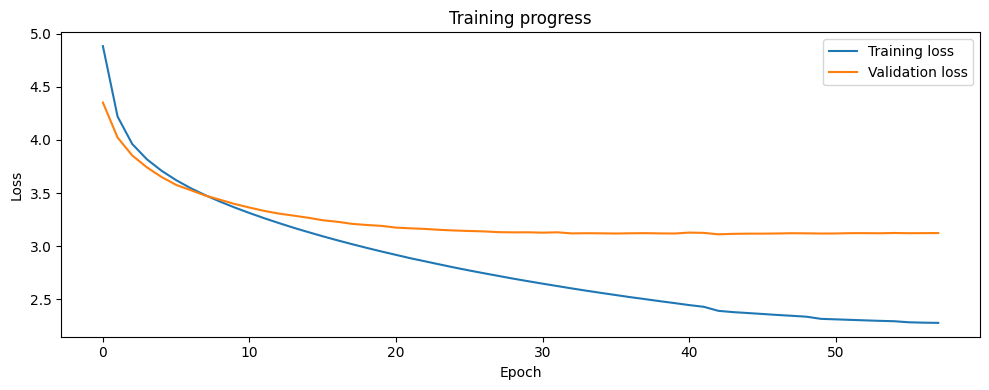

Best val_loss: 3.1123 at epoch 43
Total epochs trained: 58


In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training progress')
plt.legend()
plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_loss  = min(history.history['val_loss'])
print(f"Best val_loss: {best_loss:.4f} at epoch {best_epoch}")
print(f"Total epochs trained: {len(history.history['loss'])}")

## Cell 9 Chat with the model

The `chat` function maintains a **rolling conversation history**. Before generating a reply it prepends the last `CONTEXT_TURNS - 1` exchanges as context, exactly matching the format the model was trained on.

**Parameters:**
- `temperature` 0.7-0.8 is a good default. Lower = safer and more repetitive. Higher = more creative but risks nonsense.
- `top_p` Nucleus sampling: only consider tokens whose combined probability reaches this threshold. Prevents very unlikely tokens from being sampled.
- `REPETITION_PENALTY` Tokens already in the current reply are made less likely, preventing loops.

**Stop condition** Generation stops the moment the decoded reply contains `Human:`, which means the model has finished its Bot turn and started a new Human turn.

In [17]:
REPETITION_PENALTY = 1.3   # Tokens already in the reply are this many times less likely

def chat(model, sp, user_message, history=None, max_new_tokens=80,
         temperature=0.75, top_p=0.9):
    """
    Generate a chatbot reply using multi-turn conversation context.

    Builds a prompt from recent history plus the current message, then
    generates tokens one at a time. Stops when 'Human:' appears in the
    decoded output (end of Bot turn) or max_new_tokens is reached.
    """
    if history is None:
        history = []

    clean_message = normalize_string(user_message)

    # Build prompt from recent history + current message
    # Keep only the last CONTEXT_TURNS-1 exchanges so prompt length stays manageable
    turns = []
    for h, b in history[-(CONTEXT_TURNS - 1):]:
        turns.append(f"Human: {h}")
        turns.append(f"Bot: {b}")
    turns.append(f"Human: {clean_message}")
    turns.append("Bot:")   # Model completes from here

    prompt        = "\n".join(turns)
    prompt_ids    = sp.encode_as_ids(prompt)
    generated_ids = list(prompt_ids)

    for _ in range(max_new_tokens):
        # Use the last SEQ_LENGTH tokens; left-pad with zeros if shorter
        context = generated_ids[-SEQ_LENGTH:]
        pad_len = SEQ_LENGTH - len(context)
        padded  = [0] * pad_len + context
        x       = np.array([padded], dtype=np.int32)

        # Run forward pass. Only the very last position's logits matter
        logits = model(x, training=False)[0, -1, :].numpy()

        # Temperature scaling: divide by temperature before softmax
        # Low temperature sharpens the distribution (more predictable)
        # High temperature flattens it (more varied / random)
        logits = logits / max(temperature, 1e-8)

        # Numerically stable softmax: subtract max before exp to avoid overflow
        probs  = np.exp(logits - np.max(logits))
        probs  = probs / probs.sum()

        # Top-p (nucleus) filtering: zero out low-probability tokens
        # Sort by probability descending, find the cutoff where cumulative sum > top_p,
        # and set everything beyond that cutoff to zero.
        sorted_idx  = np.argsort(probs)[::-1]
        cumulative  = np.cumsum(probs[sorted_idx])
        cutoff_mask = cumulative > top_p
        cutoff_mask[0] = False   # Always keep at least the single most likely token
        probs[sorted_idx[cutoff_mask]] = 0.0
        probs = probs / probs.sum()

        # Repetition penalty: make tokens already in this reply less likely
        # This prevents loops like 'pattern pattern pattern pattern...'
        reply_so_far_ids = generated_ids[len(prompt_ids):]
        for token_id in set(reply_so_far_ids):
            probs[token_id] /= REPETITION_PENALTY
        probs = probs / probs.sum()

        next_id = int(np.random.choice(len(probs), p=probs))
        generated_ids.append(next_id)

        # Check stop condition: decode what we have and look for 'Human:'
        # If it appears, the model has ended its Bot turn
        reply_so_far = sp.decode_ids(generated_ids[len(prompt_ids):])
        if "Human:" in reply_so_far:
            return reply_so_far.split("Human:")[0].strip()

    return sp.decode_ids(generated_ids[len(prompt_ids):]).strip()


# Test prompts 
# History accumulates across prompts so later messages can reference earlier ones.
test_prompts = [
    "hello ?",
    "how are you doing ?",
    "where are you from ?",
    "what do you want ?",
    "i need your help .",
    "do you love me ?",
    "i know you !",
    "are you scared ?",
]

history = []
for prompt in test_prompts:
    print(f"{'─' * 60}")
    print(f"You:  {prompt}")
    reply = chat(model, sp, prompt, history=history, max_new_tokens=80, temperature=0.8, top_p=0.9)
    print(f"Bot:  {reply}")
    history.append((normalize_string(prompt), reply))
print(f"{'─' * 60}")

────────────────────────────────────────────────────────────
You:  hello ?
Bot:  hi pete . i want to talk to you about my apartment .
────────────────────────────────────────────────────────────
You:  how are you doing ?
Bot:  i am doing fine .
────────────────────────────────────────────────────────────
You:  where are you from ?
Bot:  i am from guangzhou .
────────────────────────────────────────────────────────────
You:  what do you want ?
Bot:  i want you to come here .
────────────────────────────────────────────────────────────
You:  i need your help .
Bot:  i need your help .
────────────────────────────────────────────────────────────
You:  do you love me ?
Bot:  i do not know .
────────────────────────────────────────────────────────────
You:  i know you !
Bot:  i did not ask you to think about it .
────────────────────────────────────────────────────────────
You:  are you scared ?
Bot:  i do not know . what are you scared of ?
─────────────────────────────────────────────────

## Cell 10 Save model and tokenizer

Two files are saved:
- `chatbot_model.keras` The final model state (architecture + weights)
- `chatbot_sp.model` The tokenizer

Note: `chatbot_best.keras` was already saved automatically during training by `ModelCheckpoint`. To use the best checkpoint instead of the final epoch, load `chatbot_best.keras` in Cell 11.

In [ ]:
print("Saving final model_v1 weights...")
model.save('chatbot_model_v1.keras')
print("  Saved: chatbot_model_v1.keras")

print("Saving tokenizer...")
with open('chatbot_sp_v1.model', 'wb') as f:
    f.write(sp_model_bytes)
print("  Saved: chatbot_sp_v1.model")

print("\nDone. To reload without retraining, use Cell 12.")

Saving final model weights...
  Saved: chatbot_model.keras
Saving tokenizer...
  Saved: chatbot_sp.model

Done. To reload without retraining, use Cell 12.


## Cell 11 Reload in a new session (optional)

Run Cell 1 first (imports and GPU setup), then uncomment and run this cell. After that go straight to Cell 9 to chat.

Change `chatbot_model.keras` to `chatbot_best.keras` if you want the best checkpoint from training rather than the final epoch.

In [15]:
# Uncomment everything inside the triple quotes to load a saved model

"""
import re, unicodedata
import numpy as np
import sentencepiece as spm
import ftfy
import keras

# These constants must match the values used during training
SEQ_LENGTH         = 256
CONTEXT_TURNS      = 3
REPETITION_PENALTY = 1.3

print('Loading tokenizer...')
with open('chatbot_sp.model', 'rb') as f:
    sp_model_bytes = f.read()
sp = spm.SentencePieceProcessor()
sp.load_from_serialized_proto(sp_model_bytes)
print(f'  Vocabulary size: {sp.get_piece_size()}')

print('Loading model...')
model = keras.models.load_model('chatbot_model.keras')
print('  Model loaded.')

# Helper functions required by chat() — must be defined before calling it
def unicode_to_ascii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_string(s):
    s = ftfy.fix_text(s)
    s = unicode_to_ascii(s.lower().strip())
    s = expand_contractions(s)          # <-- new step, must be before char stripping
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    s = re.sub(r"\s+", r" ", s).strip()
    return s

print('Ready. Go to Cell 10 and run the chat prompts.')
"""

'\nimport re, unicodedata\nimport numpy as np\nimport sentencepiece as spm\nimport ftfy\nimport keras\n\n# These constants must match the values used during training\nSEQ_LENGTH         = 256\nCONTEXT_TURNS      = 3\nREPETITION_PENALTY = 1.3\n\nprint(\'Loading tokenizer...\')\nwith open(\'chatbot_sp.model\', \'rb\') as f:\n    sp_model_bytes = f.read()\nsp = spm.SentencePieceProcessor()\nsp.load_from_serialized_proto(sp_model_bytes)\nprint(f\'  Vocabulary size: {sp.get_piece_size()}\')\n\nprint(\'Loading model...\')\nmodel = keras.models.load_model(\'chatbot_model.keras\')\nprint(\'  Model loaded.\')\n\n# Helper functions required by chat() — must be defined before calling it\ndef unicode_to_ascii(s):\n    return \'\'.join(\n        c for c in unicodedata.normalize(\'NFD\', s)\n        if unicodedata.category(c) != \'Mn\'\n    )\n\ndef normalize_string(s):\n    s = ftfy.fix_text(s)\n    s = unicode_to_ascii(s.lower().strip())\n    s = expand_contractions(s)          # <-- new step, mus